SS Ngobese 2235678

# 1. Project Overview
2026 South African Local Government Election Analytics

This project analyses historical municipal election data for
eThekwini Metropolitan Municipality and develops machine-learning
models to estimate selected outcomes for the 2026 Local Government
Election.

 Election dates
- Historical elections: 2011, 2016 and 2021
- Data cut-off date: 05 October 2026
- 2026 Election Day: 04 November 2026

Historical election results represent observed outcomes.

Predictions for 04 November 2026 are model estimates and are not
historical facts.

# **2. Data Sources**
 IEC Municipal Election Results

The historical election data are obtained from the Electoral
Commission of South Africa (IEC).

The analysis uses municipal election results for eThekwini
Metropolitan Municipality for:

- 2011
- 2016
- 2021

The datasets contain results at voting district and ward level
and distinguish between Ward and Proportional Representation (PR)
ballots.

Source:
Electoral Commission of South Africa (IEC)
https://www.elections.org.za/pw/
Access date:
05 October 2026

# **Environment Setup**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Importing necessary libraries**

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


# **Project Configuration**

In [ ]:
PROJECT_NAME = "eThekwini 2026 Election Analytics"

MUNICIPALITY = "eThekwini"
MUNICIPALITY_CODE = "ETH"

DATA_CUTOFF = "2026-10-05"
ELECTION_DATE = "2026-11-04"

HISTORICAL_YEARS = [2011, 2016, 2021]

print(PROJECT_NAME)
print(f"Municipality: {MUNICIPALITY}")
print(f"Historical elections: {HISTORICAL_YEARS}")
print(f"Data cut-off: {DATA_CUTOFF}")
print(f"Election date: {ELECTION_DATE}")

eThekwini 2026 Election Analytics
Municipality: eThekwini
Historical elections: [2011, 2016, 2021]
Data cut-off: 2026-10-05
Election date: 2026-11-04


## 10. Data File Organisation

The raw historical datasets are stored separately from processed
datasets.

The raw files are not modified. This allows the analysis to remain
reproducible and provides a preserved copy of the original source
data.

Expected files:

- `2011_ETH.csv`
- `2016_ETH.csv`
- `2021_ETH.csv`

## **Define project directories**

In [ ]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/eThekwini_Election_Analytics"
)

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

# Create directories if they do not already exist


In [ ]:
for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    OUTPUT_DIR,
    FIGURES_DIR,
    TABLES_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directories are ready.")
print(f"Raw data directory: {RAW_DATA_DIR}")

Project directories are ready.
Raw data directory: /content/drive/MyDrive/eThekwini_Election_Analytics/data/raw


## 11. Loading Historical Election Data

The historical IEC datasets are loaded separately so that each
election year can initially be inspected before the datasets are
combined.

The raw datasets represent:

- 2011 Local Government Election
- 2016 Local Government Election
- 2021 Local Government Election

## **Define file paths**

In [ ]:
file2011 = RAW_DATA_DIR / "2011_ETH.csv"
file2016 = RAW_DATA_DIR / "2016_ETH.csv"
file2021 = RAW_DATA_DIR / "2021_ETH.csv"

print("Expected files:")
print(file2011)
print(file2016)
print(file2021)

Expected files:
/content/drive/MyDrive/eThekwini_Election_Analytics/data/raw/2011_ETH.csv
/content/drive/MyDrive/eThekwini_Election_Analytics/data/raw/2016_ETH.csv
/content/drive/MyDrive/eThekwini_Election_Analytics/data/raw/2021_ETH.csv


# **Load the three historical election datasets**

In [ ]:
def load_csv_with_fallback(file_path):
    for encoding in ['utf-16', 'utf-8', 'latin-1', 'cp1252']:
        try:
            df = pd.read_csv(file_path, encoding=encoding)
            print(f"Successfully loaded {file_path.name} using '{encoding}' encoding.")
            return df
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Could not decode {file_path} with standard encodings.")

# Load the three historical election datasets
df_2011 = load_csv_with_fallback(file2011)
df_2016 = load_csv_with_fallback(file2016)
df_2021 = load_csv_with_fallback(file2021)

print("\nAll datasets loaded successfully.")

Successfully loaded 2011_ETH.csv using 'utf-16' encoding.
Successfully loaded 2016_ETH.csv using 'utf-8' encoding.
Successfully loaded 2021_ETH.csv using 'utf-8' encoding.

All datasets loaded successfully.


 Check the number of columns loaded

In [ ]:
print("2011 columns:", len(df_2011.columns))
print("2016 columns:", len(df_2016.columns))
print("2021 columns:", len(df_2021.columns))

print("\n2011 column names:")
print(df_2011.columns.tolist())

print("\n2016 column names:")
print(df_2016.columns.tolist())

print("\n2021 column names:")
print(df_2021.columns.tolist())

2011 columns: 11
2016 columns: 11
2021 columns: 11

2011 column names:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']

2016 column names:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']

2021 column names:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']


# Display the dimensions of each dataset

In [ ]:
print("2011 dataset:", df_2011.shape)
print("2016 dataset:", df_2016.shape)
print("2021 dataset:", df_2021.shape)

2011 dataset: (24843, 11)
2016 dataset: (40706, 11)
2021 dataset: (76740, 11)


## 12.1 Initial Dataset Inspection

Before cleaning or transforming the data, the structure of each
historical dataset is examined independently.

This initial inspection helps determine:

- Number of observations
- Number of variables
- Available geographic identifiers
- Ballot types
- Party information
- Voting and registration variables

The datasets are inspected separately before integration so that
differences between election years can be identified rather than
silently ignored.

# **Display the first five records from each election year**

In [ ]:


print("2011 DATA")
display(df_2011.head())

2011 DATA


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1,5/26/2011 4:40:02 PM
1,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,5/26/2011 4:40:02 PM
2,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN NATIONAL CONGRESS,973,5/26/2011 4:40:02 PM
3,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN PEOPLE'S CONVENTION,2,5/26/2011 4:40:02 PM
4,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AZANIAN PEOPLE'S ORGANISATION,1,5/26/2011 4:40:02 PM


In [ ]:
print("\n2016 DATA")
display(df_2016.head())


2016 DATA


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,ACADEMIC CONGRESS UNION,0,8/11/2016 12:55:57 PM
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,8/11/2016 12:55:57 PM
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN INDEPENDENT CONGRESS,19,8/11/2016 12:55:57 PM
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN MANTUNGWA COMMUNITY,0,8/11/2016 12:55:57 PM
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN NATIONAL CONGRESS,1157,8/11/2016 12:55:57 PM


In [ ]:
print("\n2021 DATA")
display(df_2021.head())


2021 DATA


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ABANTU BATHO CONGRESS,14,11/23/2021 4:26:30 PM
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACADEMIC CONGRESS UNION,0,11/23/2021 4:26:30 PM
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACTIONSA,0,11/23/2021 4:26:30 PM
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACTIVE CITIZENS COALITION,0,11/23/2021 4:26:30 PM
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0,11/23/2021 4:26:30 PM


# Inspect data types

In [ ]:
# Inspect data types

print("2011 data types")
display(df_2011.dtypes)

2011 data types


,0
Province,object
Municipality,object
Ward,object
VotingDistrict,int64
VotingStationName,object
RegisteredVoters,int64
BallotType,object
SpoiltVotes,int64
PartyName,object
TotalValidVotes,int64


In [ ]:

print("\n2016 data types")
display(df_2016.dtypes)


2016 data types


,0
Province,object
Municipality,object
Ward,object
VotingDistrict,int64
VotingStationName,object
RegisteredVoters,int64
BallotType,object
SpoiltVotes,int64
PartyName,object
TotalValidVotes,int64


In [ ]:
print("\n2021 data types")
display(df_2021.dtypes)


2021 data types


,0
Province,object
Municipality,object
Ward,object
VotingDistrict,int64
VotingStationName,object
RegisteredVoters,int64
BallotType,object
SpoiltVotes,int64
PartyName,object
TotalValidVotes,int64


## 12.2 Dataset Structure

The datasets contain electoral observations at voting-district,
ward and party level.

The `BallotType` variable distinguishes between the Ward and
Proportional Representation (PR) ballots.

The combination of geographic identifiers, ballot type and party
allows the data to be aggregated for different analytical purposes.

Before modelling, the variables will be checked for consistency
across election years.

### 13.1 Missing Values

Missing values are examined for each historical election dataset.

Missingness is important because some variables may be required for
vote-share calculations, turnout estimates, geographic aggregation
or machine-learning features.

At this stage, missing values are only identified. No values are
imputed or replaced.

In [ ]:
missing_2011 = df_2011.isna().sum()
print("Missing values — 2011")
display(missing_2011[missing_2011 > 0])

Missing values — 2011


,0


In [ ]:
missing_2016 = df_2016.isna().sum()
print("Missing values — 2016")
display(missing_2016[missing_2016 > 0])

Missing values — 2016


,0


In [ ]:
missing_2021 = df_2021.isna().sum()
print("Missing values — 2021")
display(missing_2021[missing_2021 > 0])

Missing values — 2021


,0


### 13.2 Duplicate Observations

Duplicate rows are checked because duplicate electoral records could
artificially increase party vote totals or registered-voter counts.

In [ ]:
print("Duplicate rows — 2011:", df_2011.duplicated().sum())
print("Duplicate rows — 2016:", df_2016.duplicated().sum())
print("Duplicate rows — 2021:", df_2021.duplicated().sum())

Duplicate rows — 2011: 0
Duplicate rows — 2016: 0
Duplicate rows — 2021: 0


### 13.3 Ballot Types

South African municipal elections include different ballot types.

The dataset distinguishes between:

- Ward
- Proportional Representation (PR)

These ballot types must not be mixed when calculating party support
for a specific electoral target.

The available ballot types are therefore inspected for every
election year.

In [ ]:
print("2011 ballot types:")
display(df_2011["BallotType"].value_counts())

2011 ballot types:


,count
BallotType,
PR,13617
Ward,11226


In [ ]:
print("\n2016 ballot types:")
display(df_2016["BallotType"].value_counts())


2016 ballot types:


,count
BallotType,
PR,23382
Ward,17324


In [ ]:
print("\n2021 ballot types:")
display(df_2021["BallotType"].value_counts())


2021 ballot types:


,count
BallotType,
PR,43750
Ward,32990


### 13.4 Geographic Coverage — Wards

The number of unique wards is calculated for each election year.

This is an important validation step because eThekwini's ward
structure changed between election cycles.

The observed number of wards will be retained as historical
information rather than assuming that ward identifiers represent
identical geographic areas across all years.

In [ ]:
wards_2011 = df_2011["Ward"].nunique()
wards_2016 = df_2016["Ward"].nunique()
wards_2021 = df_2021["Ward"].nunique()

print("Unique wards:")
print(f"2011: {wards_2011}")
print(f"2016: {wards_2016}")
print(f"2021: {wards_2021}")

Unique wards:
2011: 103
2016: 110
2021: 111


### 13.5 Geographic Coverage — Voting Districts

Voting districts provide a more detailed geographic level than
wards.

The number of unique voting districts is checked for each election
year because voting-district information may help us investigate
geographic comparability between historical elections and the 2026
ward structure.

In [ ]:
vd_2011 = df_2011["VotingDistrict"].nunique()
vd_2016 = df_2016["VotingDistrict"].nunique()
vd_2021 = df_2021["VotingDistrict"].nunique()

print("Unique voting districts:")
print(f"2011: {vd_2011}")
print(f"2016: {vd_2016}")
print(f"2021: {vd_2021}")

Unique voting districts:
2011: 801
2016: 866
2021: 875


### 13.6 Party Coverage

The number of unique political parties is examined for each
election year.

Party participation can change between elections. Therefore, party
categories will not automatically be assumed to be identical across
all election years.

Party-name standardisation will be addressed separately during
data preparation.

In [ ]:
parties_2011 = df_2011["PartyName"].nunique()
parties_2016 = df_2016["PartyName"].nunique()
parties_2021 = df_2021["PartyName"].nunique()

print("Unique parties:")
print(f"2011: {parties_2011}")
print(f"2016: {parties_2016}")
print(f"2021: {parties_2021}")

Unique parties:
2011: 19
2016: 28
2021: 54


### 13.7 Registered Voters

Registered voters are examined because they are important for
turnout calculations.

The same registered-voter count may appear across multiple party
records within a voting district. Therefore, registered voters must
not be summed directly across party rows.

Later aggregation will account for the structure of the dataset to
avoid double-counting registered voters.

In [ ]:
print("Registered voters — 2011")
display(df_2011["RegisteredVoters"].describe())

Registered voters — 2011


,RegisteredVoters
count,24843.000000
mean,2086.138107
std,1125.692140
min,129.000000
25%,1268.000000
50%,1987.000000
75%,2689.000000
max,7712.000000


In [ ]:
print("\nRegistered voters — 2016")
display(df_2016["RegisteredVoters"].describe())


Registered voters — 2016


,RegisteredVoters
count,40706.000000
mean,2218.242618
std,1216.222531
min,101.000000
25%,1376.000000
50%,2098.000000
75%,2827.000000
max,8099.000000


In [ ]:
print("\nRegistered voters — 2021")
display(df_2021["RegisteredVoters"].describe())


Registered voters — 2021


,RegisteredVoters
count,76740.000000
mean,2183.586591
std,1190.978470
min,107.000000
25%,1358.000000
50%,2056.000000
75%,2823.000000
max,7910.000000


### 13.8 Invalid and Negative Values

Election vote counts, registered voters and spoilt votes should not
contain negative values.

Negative values are therefore checked before any modelling or
aggregation is performed.

The check focuses on numerical electoral variables rather than
assuming that every column is numeric.

In [ ]:
def check_negative_values(df, year):
    numeric_columns = df.select_dtypes(include=np.number).columns

    negative_counts = (df[numeric_columns] < 0).sum()

    print(f"Negative values — {year}")
    display(negative_counts[negative_counts > 0])


check_negative_values(df_2011, 2011)
check_negative_values(df_2016, 2016)
check_negative_values(df_2021, 2021)

Negative values — 2011


,0


Negative values — 2016


,0


Negative values — 2021


,0


### 13.9 Party-Name Consistency

Political party names are inspected across election years.

A party may appear under different labels or may not contest every
election.

Party labels will therefore be compared before constructing a
combined historical dataset.

No party names will be changed based only on assumptions.

In [ ]:
party_names_2011 = set(df_2011["PartyName"].dropna().unique())
party_names_2016 = set(df_2016["PartyName"].dropna().unique())
party_names_2021 = set(df_2021["PartyName"].dropna().unique())

print("2011 parties:")
print(sorted(party_names_2011))

print("\n2016 parties:")
print(sorted(party_names_2016))

print("\n2021 parties:")
print(sorted(party_names_2021))

2011 parties:
['AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ALLIANSIE', 'AFRICAN CHRISTIAN DEMOCRATIC PARTY', 'AFRICAN NATIONAL CONGRESS', "AFRICAN PEOPLE'S CONVENTION", "AZANIAN PEOPLE'S ORGANISATION", 'BLACK CONSCIOUSNESS PARTY', 'CONGRESS  OF THE PEOPLE', 'DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE', 'INDEPENDENT', 'INKATHA FREEDOM PARTY', 'MINORITY FRONT', 'NATIONAL FREEDOM PARTY', 'SOCIALIST GREEN COALITION', 'SOLIDARITY PARTY', 'TRULY ALLIANCE', 'UNITED ACTION FRONT', 'UNITED DEMOCRATIC MOVEMENT', 'UNITED RESIDENTS FRONT', 'VRYHEIDSFRONT PLUS']

2016 parties:
['ACADEMIC CONGRESS UNION', 'AFRICAN CHRISTIAN DEMOCRATIC PARTY', 'AFRICAN INDEPENDENT CONGRESS', 'AFRICAN MANTUNGWA COMMUNITY', 'AFRICAN NATIONAL CONGRESS', "AFRICAN PEOPLE'S CONVENTION", 'AL JAMA-AH', 'ALLIED MOVEMENT FOR CHANGE', "AZANIAN PEOPLE'S ORGANISATION", 'CONGRESS  OF THE PEOPLE', 'DEMOCRATIC ALLIANCE', 'DEMOCRATIC LIBERAL CONGRESS', 'ECONOMIC FREEDOM FIGHTERS', 'INDEPENDENT', "INDEPENDENT PEOPLE'S PARTY", 'INDE

# **Compare party names between election years**

In [ ]:
print("Parties appearing in all three elections:")
common_parties = (
    party_names_2011
    & party_names_2016
    & party_names_2021
)

for party in sorted(common_parties):
    print(party)

print("\nNumber of common parties:", len(common_parties))

Parties appearing in all three elections:
AFRICAN CHRISTIAN DEMOCRATIC PARTY
AFRICAN NATIONAL CONGRESS
AFRICAN PEOPLE'S CONVENTION
AZANIAN PEOPLE'S ORGANISATION
CONGRESS  OF THE PEOPLE
INDEPENDENT
INKATHA FREEDOM PARTY
MINORITY FRONT
TRULY ALLIANCE
VRYHEIDSFRONT PLUS

Number of common parties: 10


## 14. Data Cleaning and Standardisation

The raw IEC datasets are preserved without modification.

Cleaned copies will be created for analysis. The cleaning process
will address:

- Column-name consistency
- Text formatting
- Data types
- Missing geographic identifiers
- Invalid numerical values
- Party-name formatting
- Ballot-type formatting

Cleaning decisions will be based on observed data rather than
assumptions.

No historical election observations will be fabricated or manually
created.

In [ ]:
clean_2011 = df_2011.copy()
clean_2016 = df_2016.copy()
clean_2021 = df_2021.copy()

print("Working copies created.")

Working copies created.


### 14.2 Standardising Column Names

Column names are standardised to make the datasets easier to work
with programmatically.

Spaces are replaced with underscores and column names are converted
to a consistent format.

In [ ]:
def standardise_columns(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_")
        .str.replace(r"[^A-Za-z0-9_]", "", regex=True)
    )

    return df

In [ ]:
clean_2011 = standardise_columns(clean_2011)
print("2011 columns:")
print(clean_2011.columns.tolist())


2011 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']


In [ ]:
clean_2016 = standardise_columns(clean_2016)
print("\n2016 columns:")
print(clean_2016.columns.tolist())



2016 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']


In [ ]:
clean_2021 = standardise_columns(clean_2021)
print("\n2021 columns:")
print(clean_2021.columns.tolist())


2021 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']


### 14.3 Cleaning Text Variables

Text-based variables are cleaned by removing unnecessary leading
and trailing whitespace.

This prevents technically different values from being created
because of accidental spaces in the source data.

The original spelling and labels are otherwise preserved.

In [ ]:
def clean_text_columns(df):
    df = df.copy()

    text_columns = df.select_dtypes(include=["object"]).columns

    for column in text_columns:
        df[column] = df[column].str.strip()

    return df

In [ ]:
clean_2011 = clean_text_columns(clean_2011)
clean_2016 = clean_text_columns(clean_2016)
clean_2021 = clean_text_columns(clean_2021)

print("Text fields cleaned.")

Text fields cleaned.


### 14.4 Numerical Data Types

Electoral counts such as registered voters, spoilt votes and valid
votes must be represented as numeric variables.

The numerical columns are converted using a controlled conversion.
Invalid values are converted to missing values rather than being
silently replaced with fabricated values.

In [ ]:
numeric_columns = [
    "RegisteredVoters",
    "SpoiltVotes",
    "TotalValidVotes"
]

In [ ]:
def convert_numeric_columns(df):
    df = df.copy()

    for column in numeric_columns:
        if column in df.columns:
            df[column] = pd.to_numeric(
                df[column],
                errors="coerce"
            )

    return df

In [ ]:
clean_2011 = convert_numeric_columns(clean_2011)
clean_2016 = convert_numeric_columns(clean_2016)
clean_2021 = convert_numeric_columns(clean_2021)

print("Numerical columns converted.")

Numerical columns converted.


Verify numerical data types

In [ ]:
print("2011:")
print(clean_2011[numeric_columns].dtypes)

2011:
RegisteredVoters    int64
SpoiltVotes         int64
TotalValidVotes     int64
dtype: object


In [ ]:
print("\n2016:")
print(clean_2016[numeric_columns].dtypes)


2016:
RegisteredVoters    int64
SpoiltVotes         int64
TotalValidVotes     int64
dtype: object


In [ ]:
print("\n2021:")
print(clean_2021[numeric_columns].dtypes)


2021:
RegisteredVoters    int64
SpoiltVotes         int64
TotalValidVotes     int64
dtype: object


### 14.6 Geographic Identifier Validation

Ward and voting-district identifiers are essential for the
geographic analysis.

Rows without a ward or voting-district identifier cannot be safely
used for ward-level analysis.

The number of missing geographic identifiers is therefore checked
before any records are removed.

In [ ]:
geographic_columns = [
    "Ward",
    "VotingDistrict"
]

for year, df in [
    (2011, clean_2011),
    (2016, clean_2016),
    (2021, clean_2021)
]:
    print(f"\n{year}")

    for column in geographic_columns:
        if column in df.columns:
            print(
                f"{column} missing:",
                df[column].isna().sum()
            )


2011
Ward missing: 0
VotingDistrict missing: 0

2016
Ward missing: 0
VotingDistrict missing: 0

2021
Ward missing: 0
VotingDistrict missing: 0


### 14.7 Electoral Count Validation

The main electoral count variables are checked for negative values
and missing values after conversion.

Negative vote counts or negative registered-voter counts would
indicate invalid records requiring investigation.

In [ ]:
for year, df in [
    (2011, clean_2011),
    (2016, clean_2016),
    (2021, clean_2021)
]:

    print(f"\n--- {year} ---")

    for column in numeric_columns:
        negative_count = (df[column] < 0).sum()
        missing_count = df[column].isna().sum()

        print(
            f"{column}: "
            f"{negative_count} negative, "
            f"{missing_count} missing"
        )


--- 2011 ---
RegisteredVoters: 0 negative, 0 missing
SpoiltVotes: 0 negative, 0 missing
TotalValidVotes: 0 negative, 0 missing

--- 2016 ---
RegisteredVoters: 0 negative, 0 missing
SpoiltVotes: 0 negative, 0 missing
TotalValidVotes: 0 negative, 0 missing

--- 2021 ---
RegisteredVoters: 0 negative, 0 missing
SpoiltVotes: 0 negative, 0 missing
TotalValidVotes: 0 negative, 0 missing


### 14.8 Ballot-Type Standardisation

Ballot-type labels are checked after text cleaning.

The expected categories are inspected rather than assuming that
every dataset uses identical labels.

In [ ]:
for year, df in [
    (2011, clean_2011),
    (2016, clean_2016),
    (2021, clean_2021)
]:

    print(f"\n{year} ballot types:")
    print(sorted(df["BallotType"].dropna().unique()))


2011 ballot types:
['PR', 'Ward']

2016 ballot types:
['PR', 'Ward']

2021 ballot types:
['PR', 'Ward']


### 14.9 Adding the Election Year

An explicit election-year variable is added to each cleaned dataset.

This allows observations from different election cycles to be
combined while retaining their historical year.

In [ ]:

clean_2011["ElectionYear"] = 2011
clean_2016["ElectionYear"] = 2016
clean_2021["ElectionYear"] = 2021

print(
    clean_2011["ElectionYear"].unique(),
    clean_2016["ElectionYear"].unique(),
    clean_2021["ElectionYear"].unique()
)

[2011] [2016] [2021]


### 14.10 Combining Historical Elections

The cleaned datasets are vertically combined into one historical
dataset.

The `ElectionYear` variable preserves the distinction between
election cycles.

The resulting dataset will be used for exploratory analysis and
feature construction.

Geographic comparability will be assessed separately before
historical ward observations are used as equivalent geographic
units.

In [ ]:
historical_df = pd.concat(
    [
        clean_2011,
        clean_2016,
        clean_2021
    ],
    ignore_index=True
)

print("Combined dataset shape:")
print(historical_df.shape)

display(historical_df.head())

Combined dataset shape:
(142289, 12)


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated,ElectionYear
0,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1,5/26/2011 4:40:02 PM,2011
1,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,5/26/2011 4:40:02 PM,2011
2,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN NATIONAL CONGRESS,973,5/26/2011 4:40:02 PM,2011
3,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN PEOPLE'S CONVENTION,2,5/26/2011 4:40:02 PM,2011
4,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AZANIAN PEOPLE'S ORGANISATION,1,5/26/2011 4:40:02 PM,2011


# **Final Cleaning**

In [ ]:
print("Dataset dimensions:")
print(historical_df.shape)

Dataset dimensions:
(142289, 12)


In [ ]:
print("\nColumns:")
print(historical_df.columns.tolist())


Columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated', 'ElectionYear']


In [ ]:
print("\nElection years:")
print(sorted(historical_df["ElectionYear"].unique()))


Election years:
[np.int64(2011), np.int64(2016), np.int64(2021)]


In [ ]:
print("\nBallot types:")
print(historical_df["BallotType"].value_counts())


Ballot types:
BallotType
PR      80749
Ward    61540
Name: count, dtype: int64


## 15. Understanding the Electoral Data

The historical dataset contains observations at the intersection of
geographic units, ballot types and political parties.

Before calculating electoral indicators, the structure of these
observations must be understood.

In particular, the analysis must distinguish between:

- Voting districts
- Wards
- Political parties
- Ward ballots
- Proportional Representation (PR) ballots

This is necessary to avoid double-counting registered voters or
mixing different electoral measures.

Selecting one voting district for structural inspection

In [ ]:

example_vd = historical_df["VotingDistrict"].dropna().iloc[0]

print("Example voting district:", example_vd)

example_data = historical_df[
    historical_df["VotingDistrict"] == example_vd
]

display(example_data)

Example voting district: 43400179


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated,ElectionYear
0,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1,5/26/2011 4:40:02 PM,2011
1,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,5/26/2011 4:40:02 PM,2011
2,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN NATIONAL CONGRESS,973,5/26/2011 4:40:02 PM,2011
3,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN PEOPLE'S CONVENTION,2,5/26/2011 4:40:02 PM,2011
4,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AZANIAN PEOPLE'S ORGANISATION,1,5/26/2011 4:40:02 PM,2011
...,...,...,...,...,...,...,...,...,...,...,...,...
65631,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,THE ORGANIC HUMANITY MOVEMENT,0,11/23/2021 4:26:30 PM,2021
65632,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,TRULY ALLIANCE,0,11/23/2021 4:26:30 PM,2021
65633,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,UNITED CHRISTIAN DEMOCRATIC PARTY,0,11/23/2021 4:26:30 PM,2021
65634,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,UNITED INDEPENDENT MOVEMENT,0,11/23/2021 4:26:30 PM,2021


### 15.1 Voting District Structure

A voting district can contain multiple party observations because
each party has its own recorded result.

The same voting district may also contain different ballot types.

Therefore, a row should not automatically be interpreted as one
unique voter or one unique voting district.

The unit of observation is examined before aggregation.

In [ ]:
print("Parties:")
display(
    example_data["PartyName"]
    .value_counts()
)

print("\nBallot types:")
display(
    example_data["BallotType"]
    .value_counts()
)

Parties:


,count
PartyName,
AFRICAN CHRISTIAN DEMOCRATIC PARTY,6
AFRICAN NATIONAL CONGRESS,6
AFRICAN PEOPLE'S CONVENTION,6
AZANIAN PEOPLE'S ORGANISATION,6
TRULY ALLIANCE,6
MINORITY FRONT,6
INKATHA FREEDOM PARTY,6
VRYHEIDSFRONT PLUS,6
CONGRESS OF THE PEOPLE,5



Ballot types:


,count
BallotType,
PR,94
Ward,73


### 15.2 Registered Voters and Party Rows

Registered voters are associated with geographic electoral units,
while party results are recorded across multiple rows.

Consequently, summing the RegisteredVoters column across all party
rows would incorrectly count the same registered voters multiple
times.

The analysis will therefore calculate registered voters at the
appropriate geographic level rather than summing party rows.

In [ ]:
display(
    example_data[
        [
            "VotingDistrict",
            "Ward",
            "RegisteredVoters",
            "BallotType",
            "PartyName",
            "TotalValidVotes"
        ]
    ]
)

,VotingDistrict,Ward,RegisteredVoters,BallotType,PartyName,TotalValidVotes
0,43400179,Ward 59500001,1438,PR,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1
1,43400179,Ward 59500001,1438,PR,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0
2,43400179,Ward 59500001,1438,PR,AFRICAN NATIONAL CONGRESS,973
3,43400179,Ward 59500001,1438,PR,AFRICAN PEOPLE'S CONVENTION,2
4,43400179,Ward 59500001,1438,PR,AZANIAN PEOPLE'S ORGANISATION,1
...,...,...,...,...,...,...
65631,43400179,Ward 59500001,2365,Ward,THE ORGANIC HUMANITY MOVEMENT,0
65632,43400179,Ward 59500001,2365,Ward,TRULY ALLIANCE,0
65633,43400179,Ward 59500001,2365,Ward,UNITED CHRISTIAN DEMOCRATIC PARTY,0
65634,43400179,Ward 59500001,2365,Ward,UNITED INDEPENDENT MOVEMENT,0


# Check Whether Registered Voters Are Consistent

In [ ]:
registered_variation = (
    historical_df
    .groupby(["ElectionYear", "VotingDistrict"])["RegisteredVoters"]
    .nunique()
    .reset_index(name="NumberOfRegisteredVoterValues")
)

inconsistent_vd = registered_variation[
    registered_variation["NumberOfRegisteredVoterValues"] > 1
]

print(
    "Voting districts with inconsistent registered-voter values:"
)
display(inconsistent_vd.head(20))

print(
    "\nNumber of inconsistent voting districts:",
    len(inconsistent_vd)
)

Voting districts with inconsistent registered-voter values:


,ElectionYear,VotingDistrict,NumberOfRegisteredVoterValues



Number of inconsistent voting districts: 0


### 15.4 Ward and Voting-District Relationship

A voting district belongs to a geographic electoral structure, while
a ward can contain multiple voting districts.

The relationship between wards and voting districts is therefore
examined before ward-level aggregation.

In [ ]:
vd_per_ward = (
    historical_df
    .groupby(["ElectionYear", "Ward"])["VotingDistrict"]
    .nunique()
    .reset_index(name="VotingDistrictCount")
)

display(vd_per_ward.head(20))

,ElectionYear,Ward,VotingDistrictCount
0,2011,Ward 59500001,11
1,2011,Ward 59500002,18
2,2011,Ward 59500003,16
3,2011,Ward 59500004,10
4,2011,Ward 59500005,6
5,2011,Ward 59500006,8
6,2011,Ward 59500007,7
7,2011,Ward 59500008,11
8,2011,Ward 59500009,8
9,2011,Ward 59500010,6


# **Summary of Geographic Structure**

In [ ]:
geographic_summary = (
    historical_df
    .groupby("ElectionYear")
    .agg(
        Wards=("Ward", "nunique"),
        VotingDistricts=("VotingDistrict", "nunique")
    )
    .reset_index()
)

display(geographic_summary)

,ElectionYear,Wards,VotingDistricts
0,2011,103,801
1,2016,110,866
2,2021,111,875


### 15.6 Party Results by Ballot Type

The Ward and PR ballots measure different aspects of municipal
electoral support.

For the analysis, the two ballot types will initially remain
separate.

This prevents the model from treating Ward and PR votes as if they
were the same electoral variable.

In [ ]:
ballot_summary = (
    historical_df
    .groupby(["ElectionYear", "BallotType"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

display(ballot_summary)

,ElectionYear,BallotType,TotalValidVotes
0,2011,PR,973728
1,2011,Ward,968553
2,2016,PR,1104552
3,2016,Ward,1121053
4,2021,PR,774736
5,2021,Ward,776015


Establishing before calculating party vote totals is whether TotalValidVotes is a party-level vote count.

In [ ]:
example_year = 2021
example_ballot = "PR"

example_ward = (
    historical_df[
        (historical_df["ElectionYear"] == example_year) &
        (historical_df["BallotType"] == example_ballot)
    ]["Ward"]
    .dropna()
    .iloc[0]
)

In [ ]:
print("Election year:", example_year)
print("Ballot type:", example_ballot)
print("Ward:", example_ward)

Election year: 2021
Ballot type: PR
Ward: Ward 59500001


In [ ]:
ward_example = historical_df[
    (historical_df["ElectionYear"] == example_year) &
    (historical_df["BallotType"] == example_ballot) &
    (historical_df["Ward"] == example_ward)
]

In [ ]:
display(
    ward_example[
        [
            "Ward",
            "VotingDistrict",
            "PartyName",
            "TotalValidVotes"
        ]
    ].head(30)
)

,Ward,VotingDistrict,PartyName,TotalValidVotes
65549,Ward 59500001,43400179,ABANTU BATHO CONGRESS,14
65550,Ward 59500001,43400179,ACADEMIC CONGRESS UNION,0
65551,Ward 59500001,43400179,ACTIONSA,0
65552,Ward 59500001,43400179,ACTIVE CITIZENS COALITION,0
65553,Ward 59500001,43400179,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0
65554,Ward 59500001,43400179,ADVANCED DYNAMIC ALLIANCE,0
65555,Ward 59500001,43400179,AFRICA RESTORATION ALLIANCE,0
65556,Ward 59500001,43400179,AFRICAN BASIC REPUBLICANS,0
65557,Ward 59500001,43400179,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0
65558,Ward 59500001,43400179,AFRICAN DEMOCRATIC CHANGE,0


## 16. Party Vote Analysis Dataset

The IEC data contains party-level vote counts for each voting district.

For party-performance analysis, votes will be aggregated by:

- Election year
- Ballot type
- Ward
- Voting district
- Party

This preserves the original electoral structure and allows party support to be analysed at both municipal and ward levels.

In [ ]:
party_votes = historical_df[[
    "ElectionYear",
    "BallotType",
    "Ward",
    "VotingDistrict",
    "PartyName",
    "TotalValidVotes"
]].copy()

In [ ]:
display(party_votes.head())

,ElectionYear,BallotType,Ward,VotingDistrict,PartyName,TotalValidVotes
0,2011,PR,Ward 59500001,43400179,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1
1,2011,PR,Ward 59500001,43400179,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0
2,2011,PR,Ward 59500001,43400179,AFRICAN NATIONAL CONGRESS,973
3,2011,PR,Ward 59500001,43400179,AFRICAN PEOPLE'S CONVENTION,2
4,2011,PR,Ward 59500001,43400179,AZANIAN PEOPLE'S ORGANISATION,1


### Check the ballot types

Before calculating party totals, we need to determine exactly which ballot types are present in each election year.

This is important because Ward and PR ballots measure different aspects of electoral support.

In [ ]:
ballot_by_year = (
    party_votes
    .groupby(["ElectionYear", "BallotType"])
    .size()
    .reset_index(name="RowCount")
)

display(ballot_by_year)

,ElectionYear,BallotType,RowCount
0,2011,PR,13617
1,2011,Ward,11226
2,2016,PR,23382
3,2016,Ward,17324
4,2021,PR,43750
5,2021,Ward,32990


### Check party vote totals by ballot type

The next table shows the largest parties under each ballot type for each historical election.

This is an exploratory check only. We will later define which ballot is appropriate for the municipal-level party projection and which is appropriate for ward-level analysis.

In [ ]:
party_totals_check = (
    party_votes
    .groupby(["ElectionYear", "BallotType", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

In [ ]:
top_parties_check = (
    party_totals_check
    .sort_values(
        ["ElectionYear", "BallotType", "TotalValidVotes"],
        ascending=[True, True, False]
    )
    .groupby(["ElectionYear", "BallotType"])
    .head(10)
)

In [ ]:
display(top_parties_check)

,ElectionYear,BallotType,PartyName,TotalValidVotes
2,2011,PR,AFRICAN NATIONAL CONGRESS,603929
7,2011,PR,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,212409
9,2011,PR,MINORITY FRONT,48064
10,2011,PR,NATIONAL FREEDOM PARTY,43606
8,2011,PR,INKATHA FREEDOM PARTY,38532
1,2011,PR,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6555
13,2011,PR,TRULY ALLIANCE,6026
3,2011,PR,AFRICAN PEOPLE'S CONVENTION,3970
6,2011,PR,CONGRESS OF THE PEOPLE,3882
14,2011,PR,UNITED ACTION FRONT,1256


## 16. Visualising the Electoral Structure

Visualisations are used to make changes in the electoral structure and party performance easier to interpret.

The first visualisations examine:

- The number of wards across election years
- The number of voting districts across election years
- The distribution of valid votes among leading parties

In [ ]:
ward_counts = (
    historical_df
    .groupby("ElectionYear")["Ward"]
    .nunique()
    .reset_index(name="NumberOfWards")
)

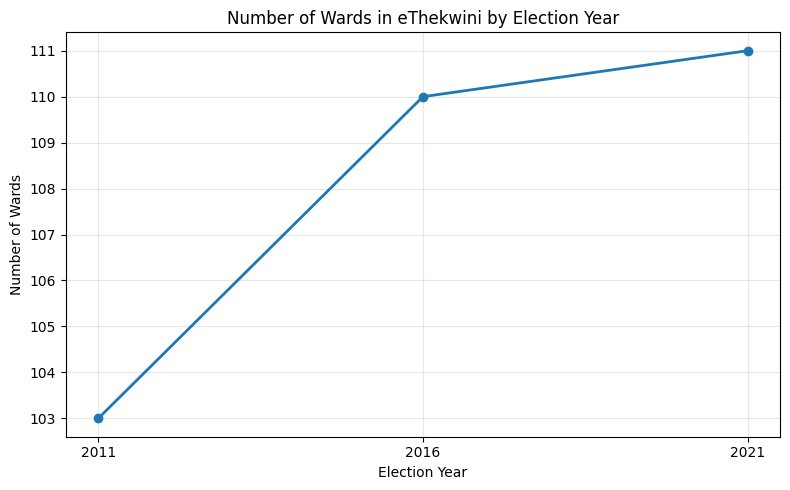

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    ward_counts["ElectionYear"],
    ward_counts["NumberOfWards"],
    marker="o",
    linewidth=2
)
plt.title("Number of Wards in eThekwini by Election Year")
plt.xlabel("Election Year")
plt.ylabel("Number of Wards")
plt.xticks(ward_counts["ElectionYear"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
vd_counts = (
    historical_df
    .groupby("ElectionYear")["VotingDistrict"]
    .nunique()
    .reset_index(name="NumberOfVotingDistricts")
)

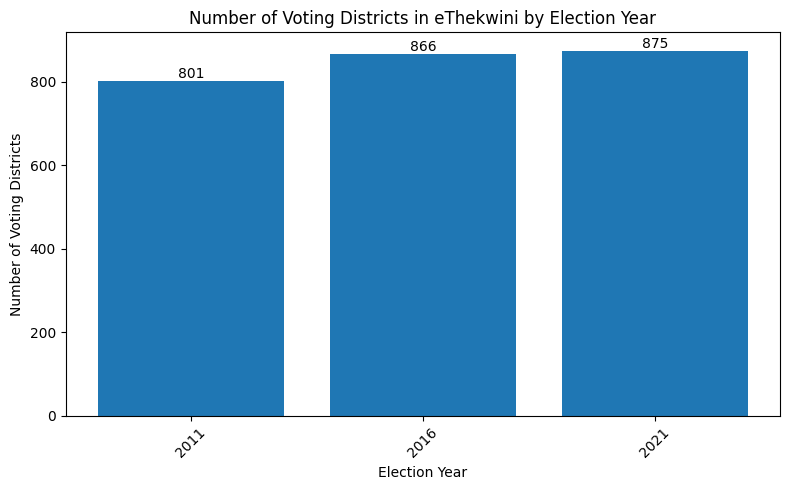

In [ ]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    vd_counts["ElectionYear"].astype(str),
    vd_counts["NumberOfVotingDistricts"]
)

plt.title("Number of Voting Districts in eThekwini by Election Year")
plt.xlabel("Election Year")
plt.ylabel("Number of Voting Districts")
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
party_totals_check = (
    party_votes[
        (party_votes["ElectionYear"] == 2021)
    ]
    .groupby("PartyName")["TotalValidVotes"]
    .sum()
    .sort_values(ascending=False)
)

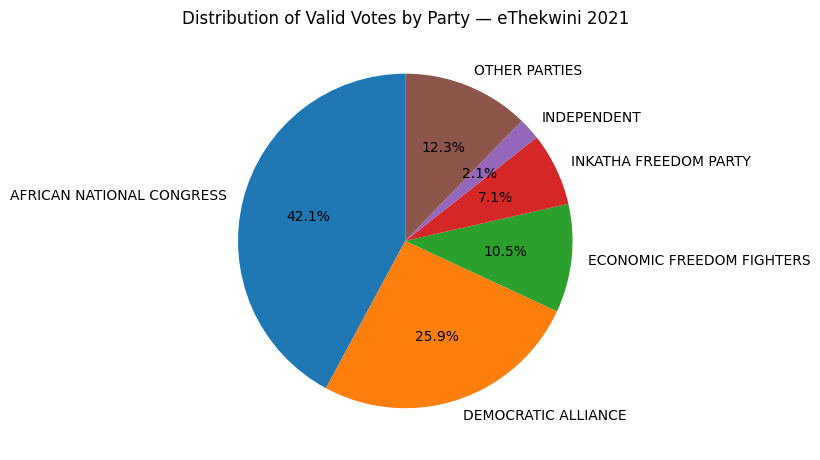

In [ ]:
top_5 =party_totals_check.head(5)

other_votes = party_totals_check.iloc[5:].sum()

pie_data = pd.concat([
    top_5,
    pd.Series({"OTHER PARTIES": other_votes})
])

plt.figure(figsize=(8, 8))

plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Valid Votes by Party — eThekwini 2021")

plt.tight_layout()
plt.show()

## 17. Historical Party Performance

This section examines how party support changed across the 2011, 2016 and 2021 local government elections.

The purpose is to identify historical voting patterns that may be useful for later modelling.

These results represent historical election data and are not 2026 predictions.

In [ ]:
major_parties = (
    party_votes
    .groupby("PartyName")["TotalValidVotes"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

major_parties

['AFRICAN NATIONAL CONGRESS',
 'DEMOCRATIC ALLIANCE',
 'DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE',
 'INKATHA FREEDOM PARTY',
 'ECONOMIC FREEDOM FIGHTERS']

In [ ]:
party_trends = (
    party_votes[
        party_votes["PartyName"].isin(major_parties)
    ]
    .groupby(["ElectionYear", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

display(party_trends)

,ElectionYear,PartyName,TotalValidVotes
0,2011,AFRICAN NATIONAL CONGRESS,1186153
1,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,408179
2,2011,INKATHA FREEDOM PARTY,80170
3,2016,AFRICAN NATIONAL CONGRESS,1246512
4,2016,DEMOCRATIC ALLIANCE,599073
5,2016,ECONOMIC FREEDOM FIGHTERS,76639
6,2016,INKATHA FREEDOM PARTY,93414
7,2021,AFRICAN NATIONAL CONGRESS,653444
8,2021,DEMOCRATIC ALLIANCE,402413
9,2021,ECONOMIC FREEDOM FIGHTERS,162447


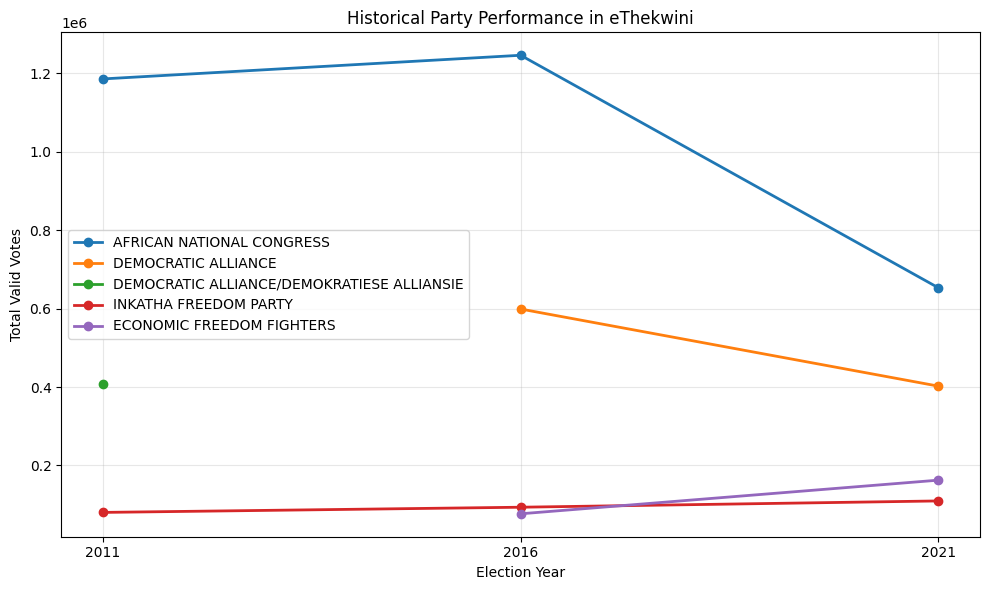

In [ ]:
plt.figure(figsize=(10, 6))

for party in major_parties:
    party_data = party_trends[
        party_trends["PartyName"] == party
    ]

    plt.plot(
        party_data["ElectionYear"],
        party_data["TotalValidVotes"],
        marker="o",
        linewidth=2,
        label=party
    )

plt.title("Historical Party Performance in eThekwini")
plt.xlabel("Election Year")
plt.ylabel("Total Valid Votes")
plt.xticks([2011, 2016, 2021])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Feature Engineering

Feature engineering converts the cleaned historical election data into variables suitable for analysis and modelling.

For party-level forecasting, the main features will include:

- Election year
- Party
- Total valid votes
- Vote share

Vote share is particularly important because raw vote totals can be affected by changes in turnout and the number of registered voters.

In [ ]:
municipal_party_votes = (
    party_votes
    .groupby(["ElectionYear", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

display(municipal_party_votes.head(20))

,ElectionYear,PartyName,TotalValidVotes
0,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,2107
1,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,14282
2,2011,AFRICAN NATIONAL CONGRESS,1186153
3,2011,AFRICAN PEOPLE'S CONVENTION,5884
4,2011,AZANIAN PEOPLE'S ORGANISATION,2638
5,2011,BLACK CONSCIOUSNESS PARTY,916
6,2011,CONGRESS OF THE PEOPLE,7310
7,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,408179
8,2011,INDEPENDENT,17226
9,2011,INKATHA FREEDOM PARTY,80170


In [ ]:
total_valid_votes = (
    municipal_party_votes
    .groupby("ElectionYear")["TotalValidVotes"]
    .sum()
    .reset_index(name="MunicipalValidVotes")
)

display(total_valid_votes)

,ElectionYear,MunicipalValidVotes
0,2011,1942281
1,2016,2225605
2,2021,1550751


In [ ]:
municipal_party_votes = municipal_party_votes.merge(
    total_valid_votes,
    on="ElectionYear",
    how="left"
)

municipal_party_votes["VoteShare"] = (
    municipal_party_votes["TotalValidVotes"]
    / municipal_party_votes["MunicipalValidVotes"]
    * 100
)

display(municipal_party_votes.head(20))

,ElectionYear,PartyName,TotalValidVotes,MunicipalValidVotes,VoteShare
0,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,2107,1942281,0.108481
1,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,14282,1942281,0.735321
2,2011,AFRICAN NATIONAL CONGRESS,1186153,1942281,61.070103
3,2011,AFRICAN PEOPLE'S CONVENTION,5884,1942281,0.302943
4,2011,AZANIAN PEOPLE'S ORGANISATION,2638,1942281,0.135820
5,2011,BLACK CONSCIOUSNESS PARTY,916,1942281,0.047161
6,2011,CONGRESS OF THE PEOPLE,7310,1942281,0.376362
7,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,408179,1942281,21.015445
8,2011,INDEPENDENT,17226,1942281,0.886895
9,2011,INKATHA FREEDOM PARTY,80170,1942281,4.127621


In [ ]:
vote_share_check = (
    municipal_party_votes
    .groupby("ElectionYear")["VoteShare"]
    .sum()
    .reset_index()
)

display(vote_share_check)

,ElectionYear,VoteShare
0,2011,100.0
1,2016,100.0
2,2021,100.0


## 18.1 Party Vote Share Over Time

Vote share provides a standardised measure of party support.

Unlike raw vote totals, vote share allows party performance to be compared across elections even when the total number of valid votes changes.

This feature will be used later when developing the 2026 municipal-level forecast.

In [ ]:
party_vote_share = (
    municipal_party_votes[
        ["ElectionYear", "PartyName", "TotalValidVotes", "MunicipalValidVotes", "VoteShare"]
    ]
    .copy()
)

display(party_vote_share.head(20))

,ElectionYear,PartyName,TotalValidVotes,MunicipalValidVotes,VoteShare
0,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,2107,1942281,0.108481
1,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,14282,1942281,0.735321
2,2011,AFRICAN NATIONAL CONGRESS,1186153,1942281,61.070103
3,2011,AFRICAN PEOPLE'S CONVENTION,5884,1942281,0.302943
4,2011,AZANIAN PEOPLE'S ORGANISATION,2638,1942281,0.135820
5,2011,BLACK CONSCIOUSNESS PARTY,916,1942281,0.047161
6,2011,CONGRESS OF THE PEOPLE,7310,1942281,0.376362
7,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,408179,1942281,21.015445
8,2011,INDEPENDENT,17226,1942281,0.886895
9,2011,INKATHA FREEDOM PARTY,80170,1942281,4.127621


Clean table for the major parties

In [ ]:
major_party_share = (
    party_vote_share[
        party_vote_share["PartyName"].isin(major_parties)
    ]
    .sort_values(["ElectionYear", "VoteShare"], ascending=[True, False])
)

display(major_party_share)

,ElectionYear,PartyName,TotalValidVotes,MunicipalValidVotes,VoteShare
2,2011,AFRICAN NATIONAL CONGRESS,1186153,1942281,61.070103
7,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,408179,1942281,21.015445
9,2011,INKATHA FREEDOM PARTY,80170,1942281,4.127621
23,2016,AFRICAN NATIONAL CONGRESS,1246512,2225605,56.007782
29,2016,DEMOCRATIC ALLIANCE,599073,2225605,26.917310
35,2016,INKATHA FREEDOM PARTY,93414,2225605,4.197241
31,2016,ECONOMIC FREEDOM FIGHTERS,76639,2225605,3.443513
61,2021,AFRICAN NATIONAL CONGRESS,653444,1550751,42.137261
72,2021,DEMOCRATIC ALLIANCE,402413,1550751,25.949556
75,2021,ECONOMIC FREEDOM FIGHTERS,162447,1550751,10.475376


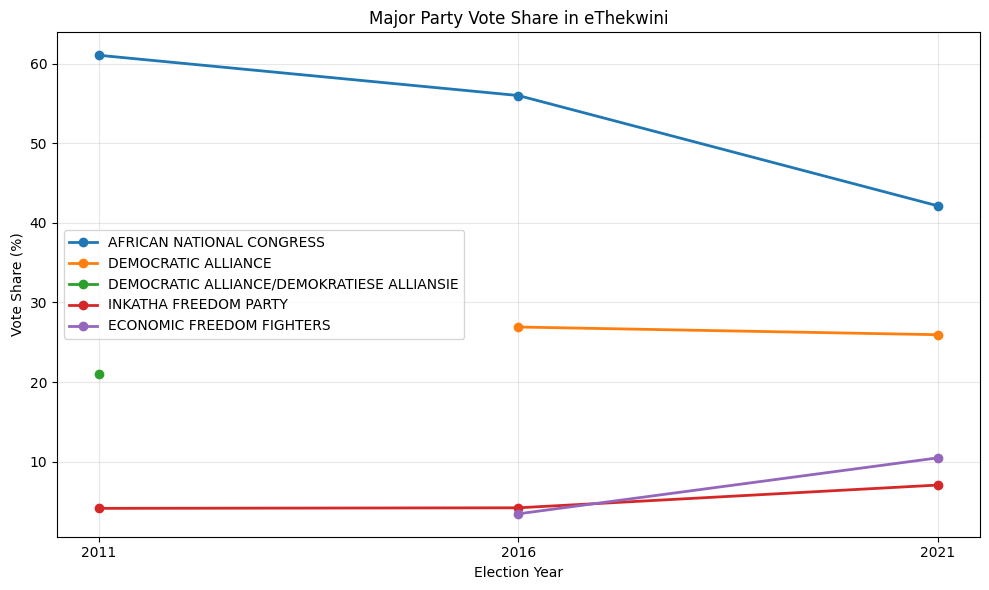

In [ ]:
plt.figure(figsize=(10, 6))

for party in major_parties:
    party_data = major_party_share[
        major_party_share["PartyName"] == party
    ]

    plt.plot(
        party_data["ElectionYear"],
        party_data["VoteShare"],
        marker="o",
        linewidth=2,
        label=party
    )

plt.title("Major Party Vote Share in eThekwini")
plt.xlabel("Election Year")
plt.ylabel("Vote Share (%)")
plt.xticks([2011, 2016, 2021])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Preparing modelling dataset


In [ ]:
model_data = municipal_party_votes.copy()

model_data = model_data[
    ["ElectionYear", "PartyName", "TotalValidVotes", "MunicipalValidVotes", "VoteShare"]
].copy()

model_data = model_data.sort_values(
    ["PartyName", "ElectionYear"]
)

display(model_data.head(20))

,ElectionYear,PartyName,TotalValidVotes,MunicipalValidVotes,VoteShare
47,2021,ABANTU BATHO CONGRESS,10864,1550751,0.700564
19,2016,ACADEMIC CONGRESS UNION,925,2225605,0.041562
48,2021,ACADEMIC CONGRESS UNION,668,1550751,0.043076
49,2021,ACTIONSA,29864,1550751,1.925777
50,2021,ACTIVE CITIZENS COALITION,14264,1550751,0.919812
51,2021,ACTIVISTS MOVEMENT OF SOUTH AFRICA,1520,1550751,0.098017
52,2021,ADVANCED DYNAMIC ALLIANCE,967,1550751,0.062357
53,2021,AFRICA RESTORATION ALLIANCE,555,1550751,0.035789
54,2021,AFRICAN BASIC REPUBLICANS,207,1550751,0.013348
0,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,2107,1942281,0.108481


Checking observations per party

In [ ]:
party_observation_counts = (
    model_data
    .groupby("PartyName")["ElectionYear"]
    .nunique()
    .sort_values(ascending=False)
)

display(party_observation_counts.head(20))

,ElectionYear
PartyName,
AFRICAN PEOPLE'S CONVENTION,3
AFRICAN CHRISTIAN DEMOCRATIC PARTY,3
TRULY ALLIANCE,3
VRYHEIDSFRONT PLUS,3
AFRICAN NATIONAL CONGRESS,3
AZANIAN PEOPLE'S ORGANISATION,3
CONGRESS OF THE PEOPLE,3
MINORITY FRONT,3
INKATHA FREEDOM PARTY,3


In [ ]:
model_parties = (
    model_data
    .groupby("PartyName")["TotalValidVotes"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

print("Parties selected for modelling:")
for party in model_parties:
    print("-", party)

Parties selected for modelling:
- AFRICAN NATIONAL CONGRESS
- DEMOCRATIC ALLIANCE
- DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE
- INKATHA FREEDOM PARTY
- ECONOMIC FREEDOM FIGHTERS
- INDEPENDENT
- MINORITY FRONT
- NATIONAL FREEDOM PARTY
- AFRICAN INDEPENDENT CONGRESS
- AFRICAN CHRISTIAN DEMOCRATIC PARTY


In [ ]:
final_model_data = model_data[
    model_data["PartyName"].isin(model_parties)
].copy()

display(final_model_data)

,ElectionYear,PartyName,TotalValidVotes,MunicipalValidVotes,VoteShare
1,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,14282,1942281,0.735321
20,2016,AFRICAN CHRISTIAN DEMOCRATIC PARTY,12103,2225605,0.543807
55,2021,AFRICAN CHRISTIAN DEMOCRATIC PARTY,11915,1550751,0.768337
21,2016,AFRICAN INDEPENDENT CONGRESS,30445,2225605,1.367943
59,2021,AFRICAN INDEPENDENT CONGRESS,10333,1550751,0.666322
2,2011,AFRICAN NATIONAL CONGRESS,1186153,1942281,61.070103
23,2016,AFRICAN NATIONAL CONGRESS,1246512,2225605,56.007782
61,2021,AFRICAN NATIONAL CONGRESS,653444,1550751,42.137261
29,2016,DEMOCRATIC ALLIANCE,599073,2225605,26.917310
72,2021,DEMOCRATIC ALLIANCE,402413,1550751,25.949556


## 19. Model Design

The historical dataset contains only three completed local-government elections
(2011, 2016 and 2021). Therefore, complex time-series models would not be
statistically well supported.

A simple and transparent forecasting approach is used instead.

The model uses historical party vote share as the target and election year as
the time-related predictor. Temporal validation is used rather than randomly
splitting the elections, because random splitting could allow information from
a later election to influence an earlier prediction.

The 2026 results are therefore treated as model estimates, not historical facts.

In [ ]:
validation_results = []

for party in model_parties:
    party_data = final_model_data[
        final_model_data["PartyName"] == party
    ].sort_values("ElectionYear")

    if len(party_data) >= 3:
        train = party_data.iloc[:2]
        test = party_data.iloc[2:]

        X_train = train[["ElectionYear"]]
        y_train = train["VoteShare"]

        X_test = test[["ElectionYear"]]
        y_test = test["VoteShare"]

        model = LinearRegression()
        model.fit(X_train, y_train)

        prediction = model.predict(X_test)[0]

        validation_results.append({
            "PartyName": party,
            "Actual2021": y_test.iloc[0],
            "Predicted2021": prediction,
            "AbsoluteError": abs(y_test.iloc[0] - prediction)
        })

validation_results = pd.DataFrame(validation_results)

display(validation_results)

,PartyName,Actual2021,Predicted2021,AbsoluteError
0,AFRICAN NATIONAL CONGRESS,42.137261,50.945462,8.808200
1,INKATHA FREEDOM PARTY,7.057677,4.266860,2.790817
2,INDEPENDENT,2.127163,7.509204,5.382041
3,MINORITY FRONT,0.487570,-4.245321,4.732891
4,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.768337,0.352293,0.416044


In [ ]:
mae = validation_results["AbsoluteError"].mean()

rmse = np.sqrt(
    mean_squared_error(
        validation_results["Actual2021"],
        validation_results["Predicted2021"]
    )
)

print(f"Validation MAE: {mae:.2f} percentage points")
print(f"Validation RMSE: {rmse:.2f} percentage points")

Validation MAE: 4.43 percentage points
Validation RMSE: 5.23 percentage points


### Model Validation Results

The temporal validation produced:

- **MAE:** 4.43 percentage points
- **RMSE:** 5.23 percentage points

The MAE indicates that, on average, the model's predicted party vote share
differed from the observed value by approximately 4.43 percentage points in
the validation test.

The RMSE of 5.23 percentage points gives greater weight to larger prediction
errors.

Because only three historical election cycles are available, these metrics
should be interpreted cautiously. They provide evidence of model performance
but do not guarantee similar accuracy for the 2026 election.

## 20. 2026 Metro-Level Forecast

The final model is trained using all available historical elections:
2011, 2016 and 2021.

The model is then used to estimate party vote share for the 2026 local
government election.

These values are model estimates and must not be presented as confirmed
election results.

In [ ]:
forecast_results = []

for party in model_parties:

    party_data = final_model_data[
        final_model_data["PartyName"] == party
    ].sort_values("ElectionYear")

    X = party_data[["ElectionYear"]]
    y = party_data["VoteShare"]

    model = LinearRegression()
    model.fit(X, y)

    predicted_share = model.predict(
        pd.DataFrame({"ElectionYear": [2026]})
    )[0]

    forecast_results.append({
        "PartyName": party,
        "PredictedVoteShare": predicted_share
    })

forecast_2026 = pd.DataFrame(forecast_results)

display(forecast_2026.sort_values(
    "PredictedVoteShare",
    ascending=False
))

,PartyName,PredictedVoteShare
0,AFRICAN NATIONAL CONGRESS,34.138874
1,DEMOCRATIC ALLIANCE,24.981802
2,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,21.015445
4,ECONOMIC FREEDOM FIGHTERS,17.507239
3,INKATHA FREEDOM PARTY,8.057569
5,INDEPENDENT,3.644303
9,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.715505
8,AFRICAN INDEPENDENT CONGRESS,-0.035298
7,NATIONAL FREEDOM PARTY,-1.839938
6,MINORITY FRONT,-2.710088


In [ ]:
forecast_2026["PredictedVoteShare"] = (
    forecast_2026["PredictedVoteShare"]
    .clip(0, 100)
)

display(
    forecast_2026.sort_values(
        "PredictedVoteShare",
        ascending=False
    )
)

,PartyName,PredictedVoteShare
0,AFRICAN NATIONAL CONGRESS,34.138874
1,DEMOCRATIC ALLIANCE,24.981802
2,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,21.015445
4,ECONOMIC FREEDOM FIGHTERS,17.507239
3,INKATHA FREEDOM PARTY,8.057569
5,INDEPENDENT,3.644303
9,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.715505
6,MINORITY FRONT,0.000000
7,NATIONAL FREEDOM PARTY,0.000000
8,AFRICAN INDEPENDENT CONGRESS,0.000000


In [ ]:
forecast_total = forecast_2026["PredictedVoteShare"].sum()

print(f"Sum of raw predicted vote shares: {forecast_total:.2f}%")

Sum of raw predicted vote shares: 110.06%


In [ ]:
forecast_2026["NormalisedVoteShare"] = (
    forecast_2026["PredictedVoteShare"]
    / forecast_2026["PredictedVoteShare"].sum()
    * 100
)

forecast_2026 = forecast_2026.sort_values(
    "NormalisedVoteShare",
    ascending=False
)

display(forecast_2026)

,PartyName,PredictedVoteShare,NormalisedVoteShare
0,AFRICAN NATIONAL CONGRESS,34.138874,31.018213
1,DEMOCRATIC ALLIANCE,24.981802,22.698196
2,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,21.015445,19.094407
4,ECONOMIC FREEDOM FIGHTERS,17.507239,15.906889
3,INKATHA FREEDOM PARTY,8.057569,7.321020
5,INDEPENDENT,3.644303,3.311175
9,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.715505,0.650100
6,MINORITY FRONT,0.000000,0.000000
7,NATIONAL FREEDOM PARTY,0.000000,0.000000
8,AFRICAN INDEPENDENT CONGRESS,0.000000,0.000000


In [ ]:
normalised_total = forecast_2026["NormalisedVoteShare"].sum()

print(f"Normalised 2026 vote share: {normalised_total:.2f}%")

Normalised 2026 vote share: 100.00%


Identify the projected leading party


In [ ]:
projected_leader = forecast_2026.iloc[0]

print("Projected leading party:", projected_leader["PartyName"])
print(
    f"Projected vote share: "
    f"{projected_leader['NormalisedVoteShare']:.2f}%"
)

Projected leading party: AFRICAN NATIONAL CONGRESS
Projected vote share: 31.02%


In [ ]:
display(party_votes["BallotType"].value_counts())

,count
BallotType,
PR,80749
Ward,61540


## 19. Final Metro-Level Forecast Dataset

For the metro-level party forecast, the Proportional Representation (PR) ballot is used.

The Ward ballot is analysed separately for ward-level predictions. This prevents the two different electoral ballots from being combined into a single vote-share measure.

In [ ]:
pr_ballot_votes = party_votes[
    party_votes["BallotType"] == "PR"
].copy()

municipal_pr_party_votes = (
    pr_ballot_votes
    .groupby(["ElectionYear", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

display(municipal_pr_party_votes.head(10))

,ElectionYear,PartyName,TotalValidVotes
0,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,949
1,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6555
2,2011,AFRICAN NATIONAL CONGRESS,603929
3,2011,AFRICAN PEOPLE'S CONVENTION,3970
4,2011,AZANIAN PEOPLE'S ORGANISATION,1238
5,2011,BLACK CONSCIOUSNESS PARTY,671
6,2011,CONGRESS OF THE PEOPLE,3882
7,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,212409
8,2011,INKATHA FREEDOM PARTY,38532
9,2011,MINORITY FRONT,48064


In [ ]:
pr_total_valid_votes = (
    municipal_pr_party_votes
    .groupby("ElectionYear")["TotalValidVotes"]
    .sum()
    .reset_index(name="MunicipalPRValidVotes")
)

municipal_pr_party_votes = municipal_pr_party_votes.merge(
    pr_total_valid_votes,
    on="ElectionYear",
    how="left"
)

municipal_pr_party_votes["VoteShare"] = (
    municipal_pr_party_votes["TotalValidVotes"]
    / municipal_pr_party_votes["MunicipalPRValidVotes"]
    * 100
)

display(municipal_pr_party_votes.head(10))

,ElectionYear,PartyName,TotalValidVotes,MunicipalPRValidVotes,VoteShare
0,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,949,973728,0.097460
1,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6555,973728,0.673186
2,2011,AFRICAN NATIONAL CONGRESS,603929,973728,62.022351
3,2011,AFRICAN PEOPLE'S CONVENTION,3970,973728,0.407711
4,2011,AZANIAN PEOPLE'S ORGANISATION,1238,973728,0.127140
5,2011,BLACK CONSCIOUSNESS PARTY,671,973728,0.068910
6,2011,CONGRESS OF THE PEOPLE,3882,973728,0.398674
7,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,212409,973728,21.813997
8,2011,INKATHA FREEDOM PARTY,38532,973728,3.957163
9,2011,MINORITY FRONT,48064,973728,4.936081


In [ ]:
pr_share_check = (
    municipal_pr_party_votes
    .groupby("ElectionYear")["VoteShare"]
    .sum()
    .reset_index(name="TotalVoteShare")
)

display(pr_share_check)

,ElectionYear,TotalVoteShare
0,2011,100.0
1,2016,100.0
2,2021,100.0


In [ ]:

top_2021_parties = (
    municipal_pr_party_votes[
        municipal_pr_party_votes["ElectionYear"] == 2021
    ]
    .sort_values("TotalValidVotes", ascending=False)
    .head(10)["PartyName"]
    .tolist()
)

print("Selected parties:")
for party in top_2021_parties:
    print("-", party)

Selected parties:
- AFRICAN NATIONAL CONGRESS
- DEMOCRATIC ALLIANCE
- ECONOMIC FREEDOM FIGHTERS
- INKATHA FREEDOM PARTY
- ACTIONSA
- AFRICAN INDEPENDENT CONGRESS
- ACTIVE CITIZENS COALITION
- AFRICAN CHRISTIAN DEMOCRATIC PARTY
- ABANTU BATHO CONGRESS
- JUSTICE AND EMPLOYMENT PARTY


In [ ]:

selected_party_data = (
    municipal_pr_party_votes[
        municipal_pr_party_votes["PartyName"].isin(top_2021_parties)
    ]
    .pivot_table(
        index="ElectionYear",
        columns="PartyName",
        values="VoteShare",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)
selected_party_data["OTHER PARTIES"] = (
    100 - selected_party_data[top_2021_parties].sum(axis=1)
)

display(selected_party_data)

PartyName,ElectionYear,ABANTU BATHO CONGRESS,ACTIONSA,ACTIVE CITIZENS COALITION,AFRICAN CHRISTIAN DEMOCRATIC PARTY,AFRICAN INDEPENDENT CONGRESS,AFRICAN NATIONAL CONGRESS,DEMOCRATIC ALLIANCE,ECONOMIC FREEDOM FIGHTERS,INKATHA FREEDOM PARTY,JUSTICE AND EMPLOYMENT PARTY,OTHER PARTIES
0,2011,0.000000,0.000000,0.000000,0.673186,0.000000,62.022351,0.000000,0.000000,3.957163,0.00000,33.347300
1,2016,0.000000,0.000000,0.000000,0.539223,1.509481,59.109123,27.541121,3.629254,4.278658,0.00000,3.393140
2,2021,0.645123,2.349316,0.805307,0.760646,1.007956,42.505705,26.328969,10.803551,7.450538,0.61479,6.728098


In [ ]:
share_columns = [
    column for column in selected_party_data.columns
    if column != "ElectionYear"
]

selected_party_data["ShareCheck"] = (
    selected_party_data[share_columns].sum(axis=1)
)

display(
    selected_party_data[
        ["ElectionYear", "ShareCheck"]
    ]
)

PartyName,ElectionYear,ShareCheck
0,2011,100.0
1,2016,100.0
2,2021,100.0


## 20. Temporal Validation of the Metro Forecast

Because only three historical election cycles are available, a chronological validation approach is used.

The model is trained on the earlier elections (2011 and 2016) and evaluated on the later 2021 election. This avoids using future election information to predict an earlier election.

In [ ]:
share_columns = [
    column for column in selected_party_data.columns
    if column not in ["ElectionYear", "ShareCheck"]
]

validation_results = []

for party in share_columns:
    train = selected_party_data[
        selected_party_data["ElectionYear"].isin([2011, 2016])
    ]

    test = selected_party_data[
        selected_party_data["ElectionYear"] == 2021
    ]

    X_train = train[["ElectionYear"]]
    y_train = train[party]

    X_test = test[["ElectionYear"]]
    y_test = test[party]

    model = LinearRegression()
    model.fit(X_train, y_train)

    prediction = model.predict(X_test)[0]

    validation_results.append({
        "Party": party,
        "Actual2021": y_test.iloc[0],
        "Predicted2021": prediction,
        "AbsoluteError": abs(y_test.iloc[0] - prediction)
    })

validation_results = pd.DataFrame(validation_results)

display(validation_results.sort_values(
    "Actual2021", ascending=False
))

,Party,Actual2021,Predicted2021,AbsoluteError
5,AFRICAN NATIONAL CONGRESS,42.505705,56.195895,13.690190
6,DEMOCRATIC ALLIANCE,26.328969,55.082241,28.753273
7,ECONOMIC FREEDOM FIGHTERS,10.803551,7.258508,3.545043
8,INKATHA FREEDOM PARTY,7.450538,4.600153,2.850385
10,OTHER PARTIES,6.728098,-26.561020,33.289118
1,ACTIONSA,2.349316,0.000000,2.349316
4,AFRICAN INDEPENDENT CONGRESS,1.007956,3.018962,2.011005
2,ACTIVE CITIZENS COALITION,0.805307,0.000000,0.805307
3,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.760646,0.405260,0.355386
0,ABANTU BATHO CONGRESS,0.645123,0.000000,0.645123


In [ ]:
mae = mean_absolute_error(
    validation_results["Actual2021"],
    validation_results["Predicted2021"]
)

rmse = np.sqrt(
    mean_squared_error(
        validation_results["Actual2021"],
        validation_results["Predicted2021"]
    )
)

print(f"Validation MAE: {mae:.2f} percentage points")
print(f"Validation RMSE: {rmse:.2f} percentage points")

Validation MAE: 8.08 percentage points
Validation RMSE: 13.99 percentage points


In [ ]:
forecast_results = []

for party in share_columns:
    X = selected_party_data[["ElectionYear"]]
    y = selected_party_data[party]

    model = LinearRegression()
    model.fit(X, y)

    predicted_2026 = model.predict(
        pd.DataFrame({"ElectionYear": [2026]})
    )[0]

    forecast_results.append({
        "Party": party,
        "PredictedVoteShare": predicted_2026
    })

forecast_2026 = pd.DataFrame(forecast_results)

forecast_2026["PredictedVoteShare"] = (
    forecast_2026["PredictedVoteShare"].clip(lower=0)
)

forecast_2026["NormalisedVoteShare"] = (
    forecast_2026["PredictedVoteShare"]
    / forecast_2026["PredictedVoteShare"].sum()
    * 100
)

forecast_2026 = forecast_2026.sort_values(
    "NormalisedVoteShare",
    ascending=False
).reset_index(drop=True)

display(forecast_2026)

,Party,PredictedVoteShare,NormalisedVoteShare
0,DEMOCRATIC ALLIANCE,44.285665,39.495040
1,AFRICAN NATIONAL CONGRESS,35.029080,31.239791
2,ECONOMIC FREEDOM FIGHTERS,15.614486,13.925381
3,INKATHA FREEDOM PARTY,8.722162,7.778637
4,ACTIONSA,3.132422,2.793570
5,AFRICAN INDEPENDENT CONGRESS,1.847102,1.647291
6,ACTIVE CITIZENS COALITION,1.073742,0.957589
7,ABANTU BATHO CONGRESS,0.860164,0.767115
8,JUSTICE AND EMPLOYMENT PARTY,0.819720,0.731046
9,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.745145,0.664539


In [ ]:
projected_leader = forecast_2026.iloc[0]

print("Projected 2026 metro-level leading party:")
print(projected_leader["Party"])

print(
    f"Projected vote share: "
    f"{projected_leader['NormalisedVoteShare']:.2f}%"
)

print(
    f"\nValidation MAE: {mae:.2f} percentage points"
)

print(
    f"Validation RMSE: {rmse:.2f} percentage points"
)

Projected 2026 metro-level leading party:
DEMOCRATIC ALLIANCE
Projected vote share: 39.50%

Validation MAE: 8.08 percentage points
Validation RMSE: 13.99 percentage points


## 21. Ward-Level Analysis and Geographic Alignment

Ward-level analysis uses the Ward ballot separately from the PR ballot.

Because ward boundaries and ward counts can change between elections, historical ward comparability is assessed using voting-district overlap. Wards that have the same ward identifier across historical elections and stronger voting-district continuity are preferred for the ward-level analysis.

The selected wards are therefore treated as historically comparable ward units rather than assuming that every historical ward is geographically identical.

In [ ]:
ward_votes = party_votes[
    party_votes["BallotType"] == "Ward"
].copy()

# Aggregate party votes within each ward
ward_party_votes = (
    ward_votes
    .groupby(
        ["ElectionYear", "Ward", "PartyName"]
    )["TotalValidVotes"]
    .sum()
    .reset_index()
)

# Calculate ward vote shares
ward_totals = (
    ward_party_votes
    .groupby(["ElectionYear", "Ward"])["TotalValidVotes"]
    .sum()
    .reset_index(name="WardValidVotes")
)

ward_party_votes = ward_party_votes.merge(
    ward_totals,
    on=["ElectionYear", "Ward"],
    how="left"
)

ward_party_votes["VoteShare"] = (
    ward_party_votes["TotalValidVotes"]
    / ward_party_votes["WardValidVotes"]
    * 100
)

display(ward_party_votes.head(10))

,ElectionYear,Ward,PartyName,TotalValidVotes,WardValidVotes,VoteShare
0,2011,Ward 59500001,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,3,8678,0.034570
1,2011,Ward 59500001,AFRICAN CHRISTIAN DEMOCRATIC PARTY,5,8678,0.057617
2,2011,Ward 59500001,AFRICAN NATIONAL CONGRESS,8301,8678,95.655681
3,2011,Ward 59500001,AFRICAN PEOPLE'S CONVENTION,10,8678,0.115234
4,2011,Ward 59500001,AZANIAN PEOPLE'S ORGANISATION,5,8678,0.057617
5,2011,Ward 59500001,CONGRESS OF THE PEOPLE,4,8678,0.046094
6,2011,Ward 59500001,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,225,8678,2.592763
7,2011,Ward 59500001,INKATHA FREEDOM PARTY,37,8678,0.426366
8,2011,Ward 59500001,MINORITY FRONT,2,8678,0.023047
9,2011,Ward 59500001,NATIONAL FREEDOM PARTY,55,8678,0.633787


Determine historical ward winners

In [ ]:
ward_winners = (
    ward_party_votes
    .sort_values(
        ["ElectionYear", "Ward", "TotalValidVotes"],
        ascending=[True, True, False]
    )
    .groupby(["ElectionYear", "Ward"])
    .first()
    .reset_index()
)

ward_winners = ward_winners[
    ["ElectionYear", "Ward", "PartyName", "TotalValidVotes", "VoteShare"]
]

display(ward_winners.head(15))

,ElectionYear,Ward,PartyName,TotalValidVotes,VoteShare
0,2011,Ward 59500001,AFRICAN NATIONAL CONGRESS,8301,95.655681
1,2011,Ward 59500002,AFRICAN NATIONAL CONGRESS,8806,91.633715
2,2011,Ward 59500003,AFRICAN NATIONAL CONGRESS,10718,86.659120
3,2011,Ward 59500004,AFRICAN NATIONAL CONGRESS,9065,84.184621
4,2011,Ward 59500005,AFRICAN NATIONAL CONGRESS,8568,88.220758
5,2011,Ward 59500006,AFRICAN NATIONAL CONGRESS,5724,59.309916
6,2011,Ward 59500007,AFRICAN NATIONAL CONGRESS,6793,80.229125
7,2011,Ward 59500008,AFRICAN NATIONAL CONGRESS,6559,60.608021
8,2011,Ward 59500009,AFRICAN NATIONAL CONGRESS,6193,58.073893
9,2011,Ward 59500010,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,9519,87.829858


In [ ]:
# Get voting-district sets for each ward and election
ward_vd_sets = (
    ward_votes
    .groupby(["ElectionYear", "Ward"])["VotingDistrict"]
    .apply(lambda x: set(x))
    .reset_index(name="VDs")
)

# Find ward IDs appearing in all three historical elections
common_wards = (
    ward_vd_sets
    .groupby("Ward")["ElectionYear"]
    .nunique()
)

common_wards = common_wards[
    common_wards == 3
].index.tolist()

print("Number of wards present in all three elections:",
      len(common_wards))

Number of wards present in all three elections: 103


In [ ]:
def jaccard_similarity(set_a, set_b):
    if not set_a and not set_b:
        return 1.0
    return len(set_a & set_b) / len(set_a | set_b)

continuity_results = []

for ward in common_wards:
    ward_data = ward_vd_sets[
        ward_vd_sets["Ward"] == ward
    ]

    vd_2011 = ward_data[
        ward_data["ElectionYear"] == 2011
    ]["VDs"].iloc[0]

    vd_2016 = ward_data[
        ward_data["ElectionYear"] == 2016
    ]["VDs"].iloc[0]

    vd_2021 = ward_data[
        ward_data["ElectionYear"] == 2021
    ]["VDs"].iloc[0]

    similarity_1 = jaccard_similarity(vd_2011, vd_2016)
    similarity_2 = jaccard_similarity(vd_2016, vd_2021)

    continuity_results.append({
        "Ward": ward,
        "2011_2016_VD_Overlap": similarity_1,
        "2016_2021_VD_Overlap": similarity_2,
        "AverageContinuity": (similarity_1 + similarity_2) / 2
    })

ward_continuity = pd.DataFrame(continuity_results)

ward_continuity = ward_continuity.sort_values(
    "AverageContinuity",
    ascending=False
)

display(ward_continuity.head(10))

,Ward,2011_2016_VD_Overlap,2016_2021_VD_Overlap,AverageContinuity
3,Ward 59500004,1.0,1.0,1.0
35,Ward 59500036,1.0,1.0,1.0
27,Ward 59500028,1.0,1.0,1.0
25,Ward 59500026,1.0,1.0,1.0
67,Ward 59500068,1.0,1.0,1.0
65,Ward 59500066,1.0,1.0,1.0
64,Ward 59500065,1.0,1.0,1.0
74,Ward 59500075,1.0,1.0,1.0
75,Ward 59500076,1.0,1.0,1.0
86,Ward 59500087,1.0,1.0,1.0


In [ ]:
selected_wards = (
    ward_continuity
    .head(3)["Ward"]
    .tolist()
)

print("Selected wards for the 2026 analysis:")
for ward in selected_wards:
    print("-", ward)

Selected wards for the 2026 analysis:
- Ward 59500004
- Ward 59500036
- Ward 59500028


In [ ]:
selected_ward_history = ward_winners[
    ward_winners["Ward"].isin(selected_wards)
].sort_values(
    ["Ward", "ElectionYear"]
)

display(selected_ward_history)

,ElectionYear,Ward,PartyName,TotalValidVotes,VoteShare
3,2011,Ward 59500004,AFRICAN NATIONAL CONGRESS,9065,84.184621
106,2016,Ward 59500004,INDEPENDENT,8167,64.998010
216,2021,Ward 59500004,AFRICAN NATIONAL CONGRESS,6906,80.677570
27,2011,Ward 59500028,AFRICAN NATIONAL CONGRESS,2917,55.636086
130,2016,Ward 59500028,AFRICAN NATIONAL CONGRESS,3737,58.702482
240,2021,Ward 59500028,AFRICAN NATIONAL CONGRESS,1208,34.994206
35,2011,Ward 59500036,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,9329,84.349005
138,2016,Ward 59500036,DEMOCRATIC ALLIANCE,9908,84.966984
248,2021,Ward 59500036,DEMOCRATIC ALLIANCE,7751,82.907263


Create ward-level features for each election

In [ ]:
ward_features = (
    ward_party_votes
    .sort_values(
        ["ElectionYear", "Ward", "VoteShare"],
        ascending=[True, True, False]
    )
    .groupby(["ElectionYear", "Ward"])
    .first()
    .reset_index()
)

In [ ]:
ward_features = ward_features[
    ["ElectionYear", "Ward", "PartyName", "VoteShare"]
].rename(columns={
    "PartyName": "PreviousWinner",
    "VoteShare": "PreviousWinnerShare"
})

Get actual winners for the following election

In [ ]:
targets = ward_winners[
    ["ElectionYear", "Ward", "PartyName"]
].rename(columns={
    "PartyName": "NextWinner"
})

# Create transition datasets:
# 2011 -> 2016
# 2016 -> 2021
# 2021 -> 2026 (prediction only)

training_rows = []

for previous_year, next_year in [(2011, 2016), (2016, 2021)]:

    previous = ward_features[
        ward_features["ElectionYear"] == previous_year
    ].copy()

    actual_next = targets[
        targets["ElectionYear"] == next_year
    ].copy()

    merged = previous.merge(
        actual_next,
        on="Ward",
        how="inner"
    )

    merged["TransitionYear"] = previous_year
    training_rows.append(merged)

classification_data = pd.concat(
    training_rows,
    ignore_index=True
)

In [ ]:

# ------------------------------------------------------------
# 3. Encode previous winner
# ------------------------------------------------------------

X = pd.get_dummies(
    classification_data[
        ["PreviousWinner", "PreviousWinnerShare"]
    ],
    columns=["PreviousWinner"],
    dtype=int
)

y = classification_data["NextWinner"]


In [ ]:
# ------------------------------------------------------------
# 4. Temporal validation
#
# Train using 2011 -> 2016
# Test using 2016 -> 2021
# ------------------------------------------------------------

train_mask = classification_data["TransitionYear"] == 2011
test_mask = classification_data["TransitionYear"] == 2016

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

# Make columns identical
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)


In [ ]:
# ------------------------------------------------------------
# 5. Classification metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

In [ ]:
print("WARD CLASSIFICATION VALIDATION")
print("=" * 45)
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

WARD CLASSIFICATION VALIDATION
Accuracy : 0.900
Precision: 0.918
Recall   : 0.900
F1 Score : 0.909


In [ ]:
# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------

labels = sorted(
    list(set(y_test) | set(y_pred))
)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[f"Actual: {x}" for x in labels],
    columns=[f"Predicted: {x}" for x in labels]
)

print("\nCONFUSION MATRIX")
display(confusion_matrix_df)


CONFUSION MATRIX


,Predicted: AFRICAN NATIONAL CONGRESS,Predicted: DEMOCRATIC ALLIANCE,Predicted: INDEPENDENT,Predicted: INKATHA FREEDOM PARTY
Actual: AFRICAN NATIONAL CONGRESS,68,2,4,0
Actual: DEMOCRATIC ALLIANCE,3,31,0,0
Actual: INDEPENDENT,0,0,0,0
Actual: INKATHA FREEDOM PARTY,0,2,0,0


In [ ]:
# ------------------------------------------------------------
# 7. Train final model on BOTH historical transitions
# ------------------------------------------------------------

final_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

final_classifier.fit(X, y)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
# ------------------------------------------------------------
# 8. Prepare 2026 features for the 3 selected wards
# ------------------------------------------------------------

latest_features = ward_features[
    (ward_features["ElectionYear"] == 2021) &
    (ward_features["Ward"].isin(selected_wards))
].copy()

X_2026 = pd.get_dummies(
    latest_features[
        ["PreviousWinner", "PreviousWinnerShare"]
    ],
    columns=["PreviousWinner"],
    dtype=int
)

X_2026 = X_2026.reindex(
    columns=X.columns,
    fill_value=0
)


In [ ]:
# ------------------------------------------------------------
# 9. Predict 2026 winner
# ------------------------------------------------------------

predicted_winners = final_classifier.predict(X_2026)

ward_predictions = pd.DataFrame({
    "Ward": latest_features["Ward"].values,
    "2021_PreviousWinner": latest_features["PreviousWinner"].values,
    "2021_WinnerShare": latest_features["PreviousWinnerShare"].values,
    "Projected2026Winner": predicted_winners
})

In [ ]:
# ------------------------------------------------------------
# 10. Display final results
# ------------------------------------------------------------

print("\nPROJECTED 2026 WARD WINNERS")
print("=" * 45)

display(
    ward_predictions.sort_values("Ward")
)


PROJECTED 2026 WARD WINNERS


,Ward,2021_PreviousWinner,2021_WinnerShare,Projected2026Winner
0,Ward 59500004,AFRICAN NATIONAL CONGRESS,80.677570,AFRICAN NATIONAL CONGRESS
1,Ward 59500028,AFRICAN NATIONAL CONGRESS,34.994206,DEMOCRATIC ALLIANCE
2,Ward 59500036,DEMOCRATIC ALLIANCE,82.907263,DEMOCRATIC ALLIANCE
